# Understanding Nyquist Frequency and FFT

This notebook demonstrates the basics of the Fast Fourier Transform (FFT) and the importance of the Nyquist-Shannon sampling theorem.

**Key Concepts:**

1.  **Signal:** We'll start by creating a simple sine wave, which is a signal with a single, known frequency.
2.  **Sampling:** Computers can't work with continuous signals. We need to sample the signal at discrete time intervals. The number of samples per second is the **sampling rate (or sampling frequency)**.
3.  **FFT (Fast Fourier Transform):** This is an algorithm that converts a signal from its original domain (usually time) to the frequency domain. It allows us to see which frequencies are present in the signal.
4.  **Nyquist Frequency:** The Nyquist-Shannon sampling theorem states that to accurately reconstruct a signal, the sampling rate must be at least twice the highest frequency present in the signal. This minimum required sampling rate (2 * f_max) is called the **Nyquist rate**. The **Nyquist frequency** is half of the sampling rate (`sampling_rate / 2`). Any frequency above the Nyquist frequency will be incorrectly represented, an effect called **aliasing**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Set up the plotting style
plt.style.use('seaborn-v0_8-whitegrid')

## Part 1: Analyzing a Single Frequency Signal (Sampled Correctly)

First, we'll create a signal with a frequency of 50 Hz and sample it at 1000 Hz. This sampling rate is well above the Nyquist rate (2 * 50 Hz = 100 Hz), so we expect to see the correct frequency after performing the FFT.

In [2]:
# --- Signal Parameters ---
sampling_rate = 1000  # in Hz (samples per second)
duration = 2          # in seconds
signal_freq = 50      # in Hz

# --- Generate the Signal ---
# Create a time vector from 0 to 'duration' with 'sampling_rate * duration' points
t = np.linspace(0, duration, int(sampling_rate * duration), endpoint=False)

# Create the sinusoidal signal
# y = A * sin(2 * pi * f * t + phase)
signal = np.sin(2 * np.pi * signal_freq * t)

# --- Nyquist Calculation ---
nyquist_freq = sampling_rate / 2
print(f"Sampling Rate: {sampling_rate} Hz")
print(f"Signal Frequency: {signal_freq} Hz")
print(f"Nyquist Frequency: {nyquist_freq} Hz")
print(f"Is signal frequency < Nyquist frequency? {signal_freq < nyquist_freq}")

Sampling Rate: 1000 Hz
Signal Frequency: 50 Hz
Nyquist Frequency: 500.0 Hz
Is signal frequency < Nyquist frequency? True


### Plot the Time-Domain Signal

Let's visualize the first few cycles of the signal to see what it looks like in the time domain.

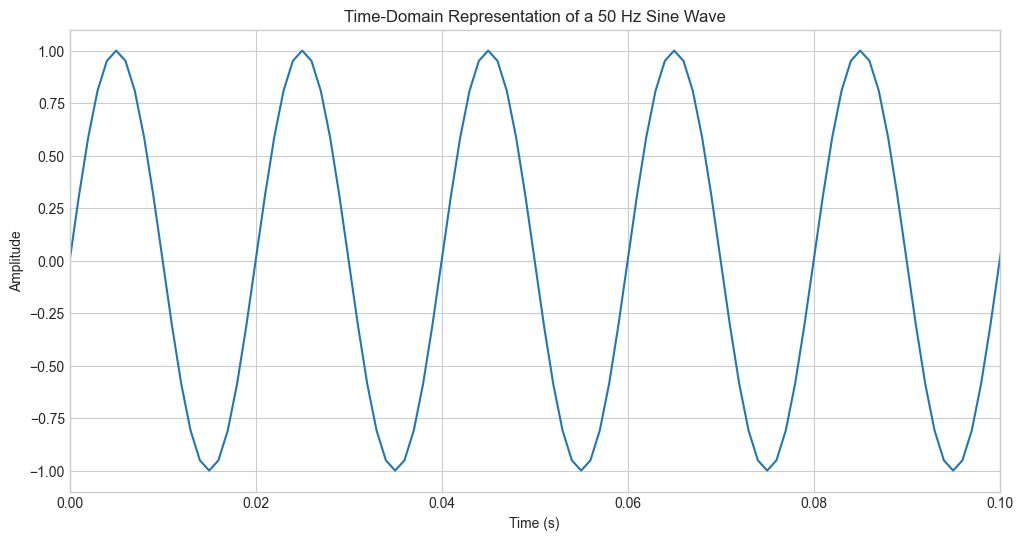

In [3]:
plt.figure(figsize=(12, 6))
plt.plot(t, signal)
plt.title('Time-Domain Representation of a 50 Hz Sine Wave')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
# Limit the x-axis to show only the first few cycles for clarity
plt.xlim(0, 0.1)
plt.show()

### Perform the FFT and Plot the Frequency Spectrum

Now, we'll apply the FFT to transform the signal into the frequency domain. The result of the FFT is an array of complex numbers. We are interested in the magnitude (or amplitude) of these numbers, which tells us the strength of each frequency component.

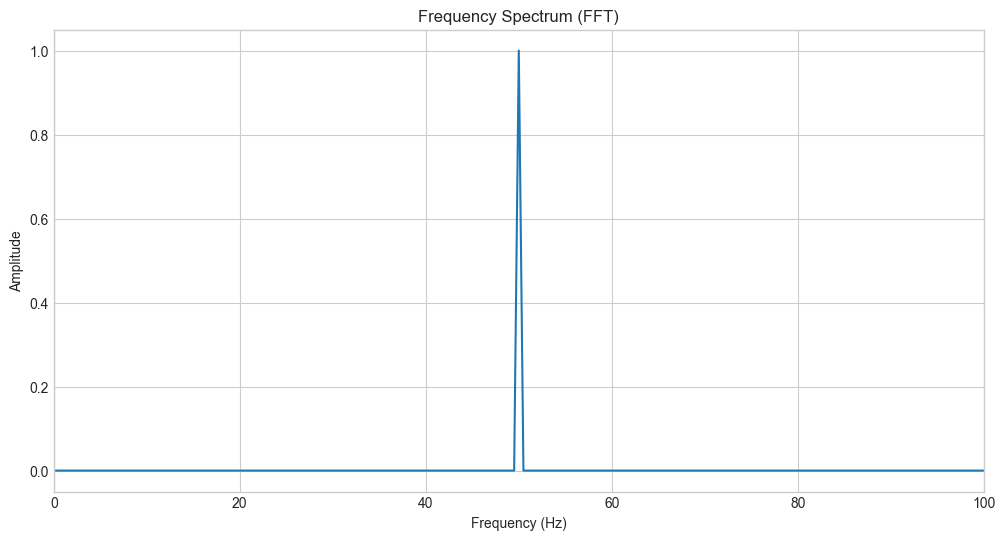

The FFT correctly detected the peak frequency at: 50.00 Hz


In [4]:
# --- Perform FFT ---
# Number of samples
N = len(signal)

# Compute the FFT
fft_result = np.fft.fft(signal)

# Compute the frequency bins for the x-axis
# np.fft.fftfreq generates the frequencies corresponding to the FFT output
# freq_bins = np.fft.fftfreq(N, deltaT)
freq_bins = np.fft.fftfreq(N, 1 / sampling_rate)

# We are only interested in the positive frequencies, so we'll take the first half of the array
# The FFT output is symmetric, so the negative frequencies are redundant for real-valued signals.
half_N = N // 2

positive_freqs = freq_bins[:half_N]
# Calculate the magnitude (amplitude) of the FFT result and normalize it
fft_magnitude = np.abs(fft_result[:half_N]) * (2 / N)

# --- Plot the Frequency Spectrum ---
plt.figure(figsize=(12, 6))
plt.plot(positive_freqs, fft_magnitude)
plt.title('Frequency Spectrum (FFT)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
# Optional: Limit x-axis for a clearer view of the peak
plt.xlim(0, 100)
plt.show()

# Find the peak frequency
peak_freq_index = np.argmax(fft_magnitude)
detected_freq = positive_freqs[peak_freq_index]
print(f"The FFT correctly detected the peak frequency at: {detected_freq:.2f} Hz")

As expected, the plot shows a single, sharp peak exactly at 50 Hz. This is because our sampling rate was high enough to capture the signal's frequency content accurately.

## Part 2: Demonstrating Aliasing (Sampling Below Nyquist)

Now, let's see what happens when we violate the Nyquist-Shannon theorem. We will create a new signal with a frequency of **90 Hz**, but we will sample it at only **100 Hz**. 

* **Signal Frequency:** 90 Hz
* **Sampling Rate:** 100 Hz
* **Nyquist Frequency:** 100 / 2 = 50 Hz

Since the signal frequency (90 Hz) is *greater* than the Nyquist frequency (50 Hz), we should see aliasing. The 90 Hz signal will appear as a different, lower frequency in our FFT plot.

In [5]:
# --- Signal Parameters ---
bad_sampling_rate = 100  # in Hz
duration = 2             # in seconds
high_signal_freq = 90    # in Hz

# --- Generate the Signal ---
t_bad = np.linspace(0, duration, int(bad_sampling_rate * duration), endpoint=False)
signal_aliased = np.sin(2 * np.pi * high_signal_freq * t_bad)

# --- Nyquist Calculation ---
nyquist_freq_bad = bad_sampling_rate / 2
print(f"Sampling Rate: {bad_sampling_rate} Hz")
print(f"Signal Frequency: {high_signal_freq} Hz")
print(f"Nyquist Frequency: {nyquist_freq_bad} Hz")
print(f"Is signal frequency < Nyquist frequency? {high_signal_freq < nyquist_freq_bad}")

Sampling Rate: 100 Hz
Signal Frequency: 90 Hz
Nyquist Frequency: 50.0 Hz
Is signal frequency < Nyquist frequency? False


### Perform FFT on the Poorly Sampled Signal

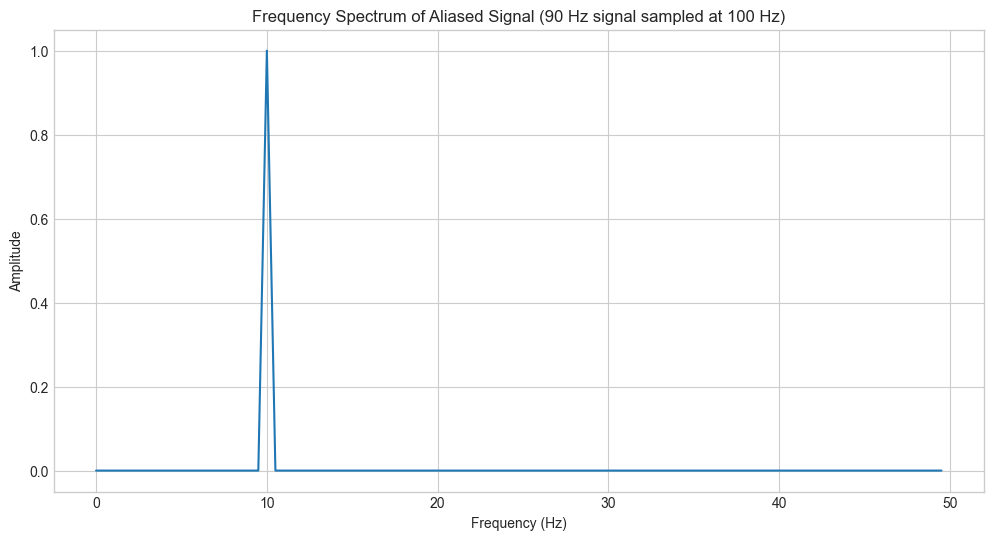

The original signal was 90 Hz.
The FFT incorrectly detected a peak at: 10.00 Hz

This is aliasing!


In [6]:
# --- Perform FFT ---
N_bad = len(signal_aliased)
fft_result_bad = np.fft.fft(signal_aliased)
freq_bins_bad = np.fft.fftfreq(N_bad, 1 / bad_sampling_rate)

half_N_bad = N_bad // 2
positive_freqs_bad = freq_bins_bad[:half_N_bad]
fft_magnitude_bad = np.abs(fft_result_bad[:half_N_bad]) * (2 / N_bad)

# --- Plot the Frequency Spectrum ---
plt.figure(figsize=(12, 6))
plt.plot(positive_freqs_bad, fft_magnitude_bad)
plt.title('Frequency Spectrum of Aliased Signal (90 Hz signal sampled at 100 Hz)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

# Find the peak frequency
peak_freq_index_bad = np.argmax(fft_magnitude_bad)
detected_freq_bad = positive_freqs_bad[peak_freq_index_bad]

print(f"The original signal was 90 Hz.")
print(f"The FFT incorrectly detected a peak at: {detected_freq_bad:.2f} Hz")
print("\nThis is aliasing!")

### Conclusion

The FFT plot for the second case shows a peak at **10 Hz**, not 90 Hz! The high-frequency signal is masquerading as a low-frequency one. 

The aliased frequency can be calculated as:
`f_alias = |f_signal - n * f_sampling|`

In our case: `|90 Hz - 1 * 100 Hz| = |-10 Hz| = 10 Hz`.

This demonstration highlights the critical importance of choosing a sampling rate that is at least twice the maximum frequency you expect to find in your signal. Otherwise, the results of your frequency analysis will be incorrect and misleading.